In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Chapter 2 

## 1-Diagonalizationof the simple 1D tight-binding model of a particle hopping on a translationally invariant lattice:

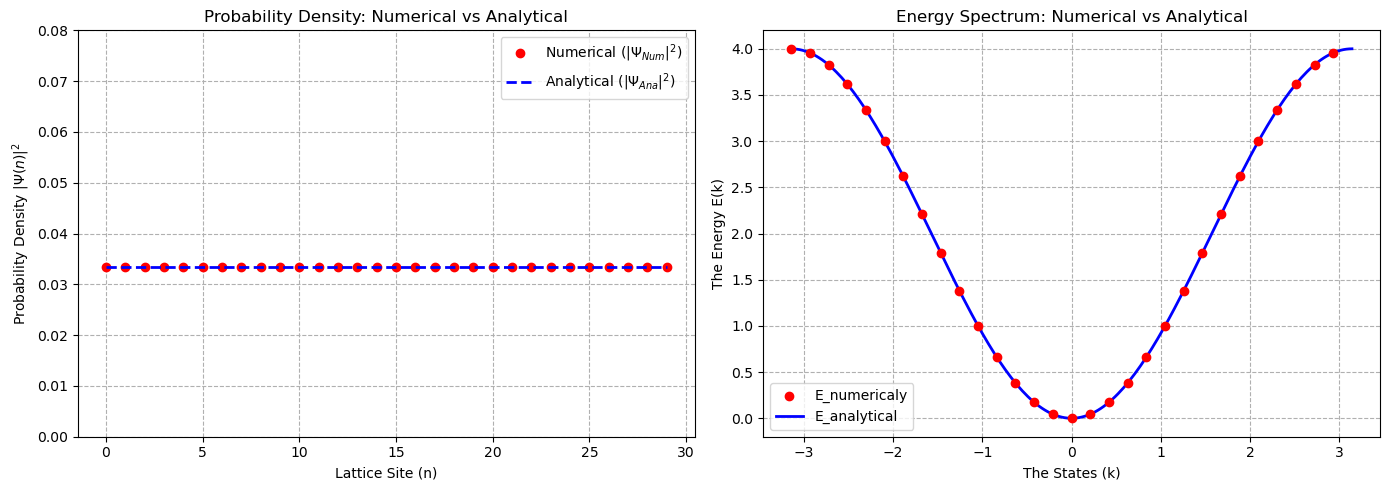

Mean Error for Probability Density: 8.294e-16
Mean Error for Energy Spectrum E(k): 5.014e-16


In [185]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# 1. System parameters
N  = 30  # Number of atoms (sites)
t  = 1   # Interaction energy (Hopping parameter)
E0 = 2   # Initial energy (On-site energy)
a  = 1   # Lattice constant (distance between atoms)


# 2. Construct the Hamiltonian H
# Main diagonal:
H = np.eye(N) * E0

# Hopping terms: 
for i in range(N - 1):
    H[i, i+1] = -t
    H[i+1, i] = -t

# Periodic Boundary Conditions
H[0, N-1] = -t
H[N-1, 0] = -t

# Numerical Energy Spectrum
E_Num, psi = np.linalg.eigh(H) 

# 3. Plotting Probability Density and Energy Spectrum E(k) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#  Numerical and Analytical Probability Density 
Pd_Num = np.abs(psi[:, 0])**2
n_sites = np.arange(N)  
k_ground = 0            
Psi_analytical = (1 / np.sqrt(N)) * np.exp(1j * k_ground * n_sites * a)
Pd_Ana = np.abs(Psi_analytical)**2

ax1.plot(range(N), Pd_Num, color='red', marker='o', linestyle='', label='Numerical ($|\Psi_{Num}|^2$)')
ax1.plot(range(N), Pd_Ana, color='blue', linestyle='--', linewidth=2, label='Analytical ($|\Psi_{Ana}|^2$)')
ax1.set_title("Probability Density: Numerical vs Analytical")
ax1.set_xlabel("Lattice Site (n)")
ax1.set_ylabel(r"Probability Density $|\Psi(n)|^2$")
ax1.set_ylim(0, 0.08) 
ax1.grid(True, linestyle='--')
ax1.legend()

#  Numerical and Analytical Energy Spectrum E(k) 
indices = np.arange(30)
m = (indices + 1) // 2 * np.where(indices % 2 == 0, 1, -1)
k_Num = (2 * np.pi * m) / (N * a)
k_Ana = np.linspace(-np.pi/a, np.pi/a, 200)

# Analytical sorting
E_Ana_at_kNum = E0 - 2 * t * np.cos(k_Num * a)
E_Ana = E0 - 2 * t * np.cos(k_Ana * a)

ax2.scatter(k_Num, np.sort(E_Num), color='red', label='E_numericaly', zorder=3)
ax2.plot(k_Ana, E_Ana, label=r'E_analytical', color='blue', linewidth=2) 
ax2.set_title("Energy Spectrum: Numerical vs Analytical")
ax2.set_xlabel("The States (k)")
ax2.set_ylabel("The Energy E(k)")
ax2.grid(True, linestyle='--')
ax2.legend()

# Save and Show the figure
plt.tight_layout()
plt.savefig("prob_Energy_1D.png")
plt.show()


# 4. Mean Error Tracking

error_Pd = np.abs(Pd_Num - Pd_Ana)
error_E = np.abs(np.sort(E_Num) - np.sort(E_Ana_at_kNum))

print(f"Mean Error for Probability Density: {np.mean(error_Pd):.3e}")
print(f"Mean Error for Energy Spectrum E(k): {np.mean(error_E):.3e}")

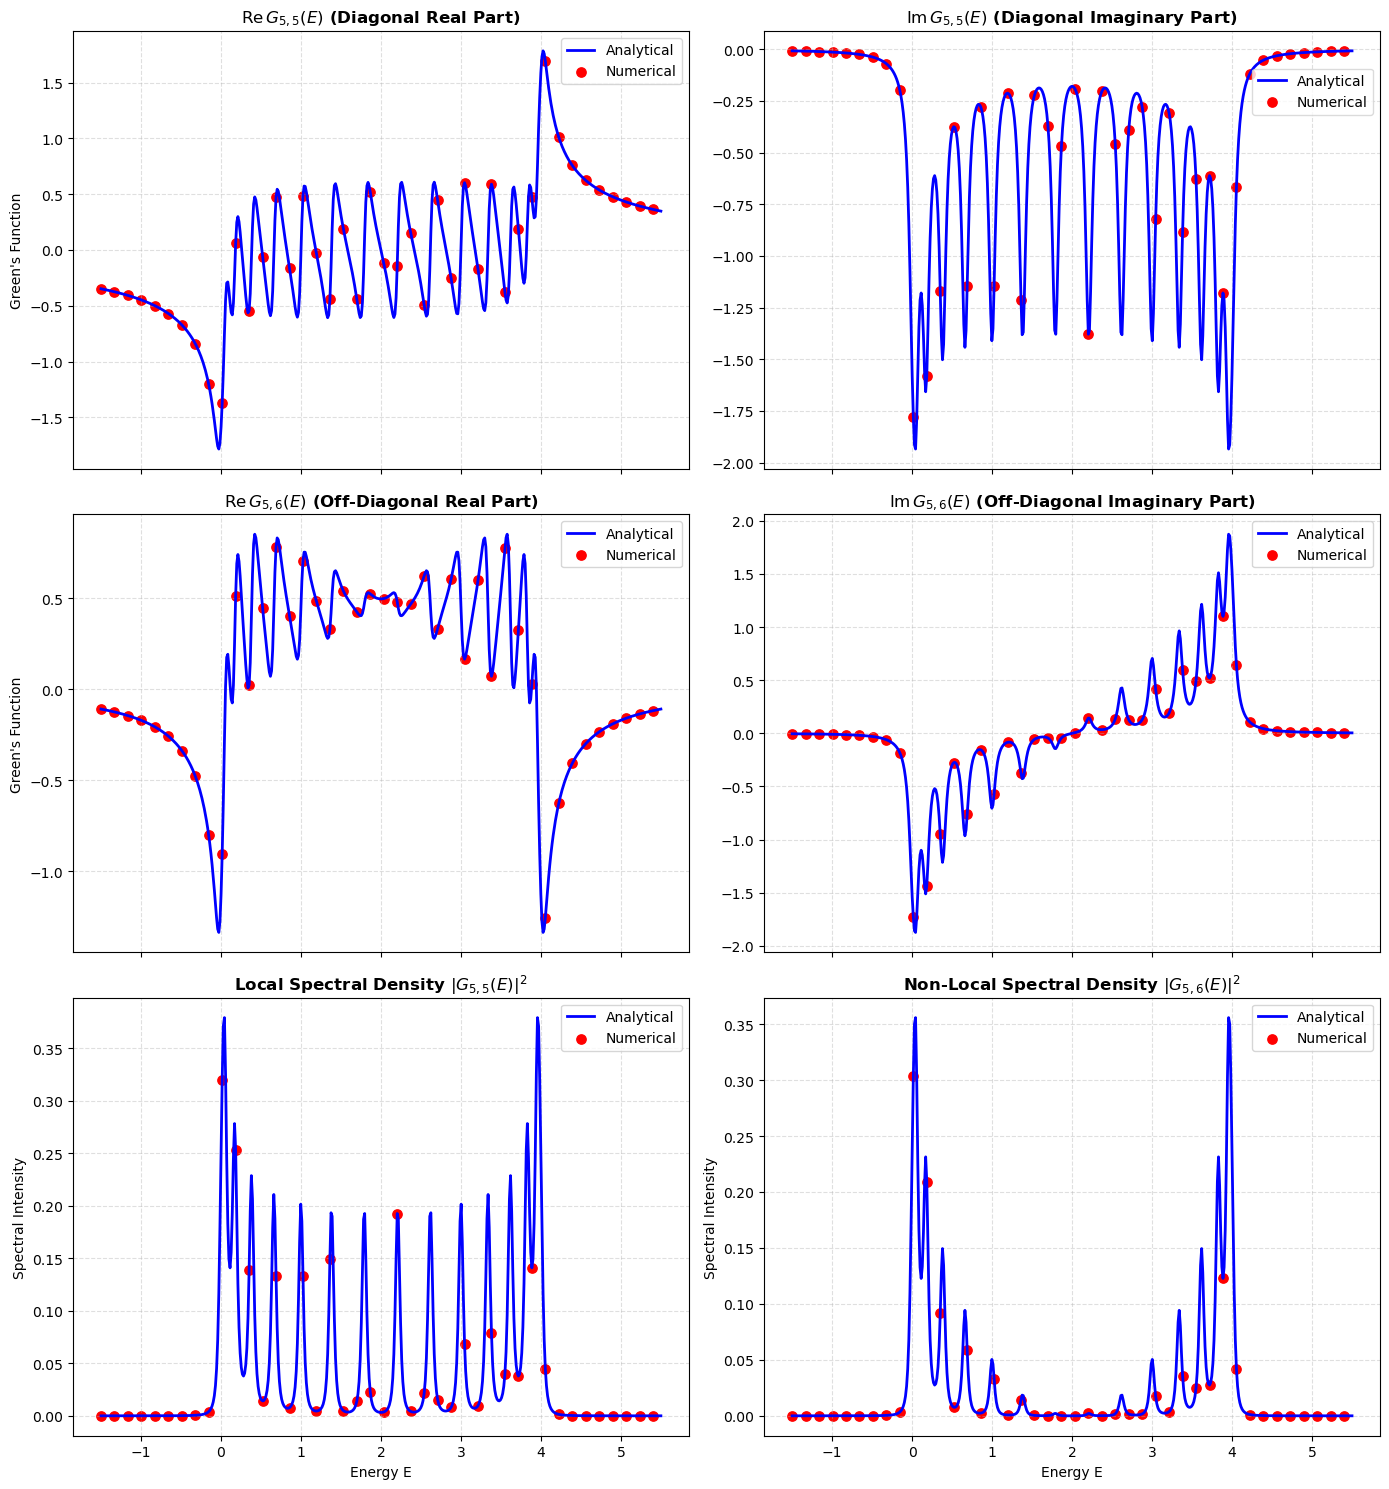

Mean Error for Re G5,5: 1.089e-15
Mean Error for Im G5,5: 1.128e-15
Mean Error for Re G5,6: 1.712e-15
Mean Error for Im G5,6: 1.688e-15
Mean Error for |G5,5|^2: 2.039e-16
Mean Error for |G5,6|^2: 1.515e-16


In [196]:
import numpy as np
import matplotlib.pyplot as plt

# 1. System Parameters
N = 30          # Number of atoms (sites)
t = 1.0         # Interaction energy (Hopping parameter)
E0 = 2.0        # On-site energy (baseline potential)
a = 1.0         # Lattice constant (distance between atoms)
eta = 0.05      # Damping factor for Green's functions

E_values = np.linspace(-1.5, 5.5, 500)

# 2. Numerical Hamiltonian Matrix Construction
H = np.zeros((N, N), dtype=complex)
for i in range(N):
    H[i, i] = E0
    H[i, (i + 1) % N] = -t
    H[i, (i - 1) % N] = -t

# 3. Analytical and Numerical Green's Function Calculations
G_local_ana = []
G_non_ana = []
G_local_num = []
G_non_num = []

idx_local = 0
idx_non_local = 1

k_vals = (2 * np.pi / (N * a)) * np.arange(N)

for E in E_values:
    z = E + 1j * eta
    
    # A) Analytical Calculation 
    sum_diag = 0.0
    sum_off = 0.0
    for k in k_vals:
        Ek = E0 - 2 * t * np.cos(k * a)
        fact = 1.0 / (z - Ek)
        sum_diag += fact
        sum_off += fact * np.exp(1j * k * a) 
        
    G_local_ana.append(sum_diag / N)
    G_non_ana.append(sum_off / N)
    
    # B) Numerical Matrix Inversion 
    I = np.eye(N, dtype=complex)
    G_matrix = np.linalg.inv(z * I - H)
    G_local_num.append(G_matrix[idx_local, idx_local])
    G_non_num.append(G_matrix[idx_non_local, idx_local])

# Convert collected lists into numpy arrays
G_local_ana, G_non_ana = np.array(G_local_ana), np.array(G_non_ana)
G_local_num, G_non_num = np.array(G_local_num), np.array(G_non_num)


# 4. Spectral Density Calculation
A_local_ana = np.abs(-1.0 / np.pi * np.imag(G_local_ana))**2
A_non_ana   = np.abs(-1.0 / np.pi * np.imag(G_non_ana))**2

A_local_num = np.abs(-1.0 / np.pi * np.imag(G_local_num))**2
A_non_num   = np.abs(-1.0 / np.pi * np.imag(G_non_num))**2

# 5. Plotting: 
fig, axs = plt.subplots(3, 2, figsize=(14, 15), sharex=True)
step = 12 

#  G55 Real Part 
axs[0, 0].plot(E_values, np.real(G_local_ana), color='blue', linewidth=2, label='Analytical')
axs[0, 0].scatter(E_values[::step], np.real(G_local_num)[::step], color='red', marker='o', s=45, label='Numerical')
axs[0, 0].set_title(r"$\mathrm{Re}\,G_{5,5}(E)$ (Diagonal Real Part)", fontweight='bold')
axs[0, 0].set_ylabel("Green's Function")
axs[0, 0].grid(True, linestyle='--', alpha=0.4)
axs[0, 0].legend(loc='upper right')

#  G55 Imaginary Part 
axs[0, 1].plot(E_values, np.imag(G_local_ana), color='blue', linewidth=2, label='Analytical')
axs[0, 1].scatter(E_values[::step], np.imag(G_local_num)[::step], color='red', marker='o', s=45, label='Numerical')
axs[0, 1].set_title(r"$\mathrm{Im}\,G_{5,5}(E)$ (Diagonal Imaginary Part)", fontweight='bold')
axs[0, 1].grid(True, linestyle='--', alpha=0.4)
axs[0, 1].legend(bbox_to_anchor=(1.00, 0.93), loc='upper right', frameon=True, facecolor='white', edgecolor='lightgray')


#  G56 Real Part 
axs[1, 0].plot(E_values, np.real(G_non_ana), color='blue', linewidth=2, label='Analytical')
axs[1, 0].scatter(E_values[::step], np.real(G_non_num)[::step], color='red', marker='o', s=45, label='Numerical')
axs[1, 0].set_title(r"$\mathrm{Re}\,G_{5,6}(E)$ (Off-Diagonal Real Part)", fontweight='bold')
axs[1, 0].set_ylabel("Green's Function")
axs[1, 0].grid(True, linestyle='--', alpha=0.4)
axs[1, 0].legend(loc='upper right')

#  G56 Imaginary Part 
axs[1, 1].plot(E_values, np.imag(G_non_ana), color='blue', linewidth=2, label='Analytical')
axs[1, 1].scatter(E_values[::step], np.imag(G_non_num)[::step], color='red', marker='o', s=45, label='Numerical')
axs[1, 1].set_title(r"$\mathrm{Im}\,G_{5,6}(E)$ (Off-Diagonal Imaginary Part)", fontweight='bold')
axs[1, 1].grid(True, linestyle='--', alpha=0.4)
axs[1, 1].legend(loc='upper right')


# Local Density
axs[2, 0].plot(E_values, A_local_ana, color='blue', linewidth=2, label='Analytical')
axs[2, 0].scatter(E_values[::step], A_local_num[::step], color='red', marker='o', s=45, label='Numerical')
axs[2, 0].set_title(r"Local Spectral Density $|G_{5,5}(E)|^2$", fontweight='bold')
axs[2, 0].set_xlabel("Energy E")
axs[2, 0].set_ylabel("Spectral Intensity")
axs[2, 0].grid(True, linestyle='--', alpha=0.4)
axs[2, 0].legend()

# Non-Local Density
axs[2, 1].plot(E_values, A_non_ana, color='blue', linewidth=2, label='Analytical')
axs[2, 1].scatter(E_values[::step], A_non_num[::step], color='red', marker='o', s=45, label='Numerical')
axs[2, 1].set_title(r"Non-Local Spectral Density $|G_{5,6}(E)|^2$", fontweight='bold')
axs[2, 1].set_xlabel("Energy E")
axs[2, 1].set_ylabel("Spectral Intensity")
axs[2, 1].grid(True, linestyle='--', alpha=0.4)
axs[2, 1].legend()

plt.tight_layout()
plt.savefig("1D_Spectral_Density.png", dpi=300)
plt.show()

# 6. Error Calculation
error_G11_real = np.abs(np.real(G_local_ana) - np.real(G_local_num))
error_G11_imag = np.abs(np.imag(G_local_ana) - np.imag(G_local_num))
error_G21_real = np.abs(np.real(G_non_ana) - np.real(G_non_num))
error_G21_imag = np.abs(np.imag(G_non_ana) - np.imag(G_non_num))
error_A_local = np.abs(A_local_ana - A_local_num)
error_A_non   = np.abs(A_non_ana - A_non_num)

print(f"Mean Error for Re G5,5: {np.mean(error_G11_real):.3e}")
print(f"Mean Error for Im G5,5: {np.mean(error_G11_imag):.3e}")
print(f"Mean Error for Re G5,6: {np.mean(error_G21_real):.3e}")
print(f"Mean Error for Im G5,6: {np.mean(error_G21_imag):.3e}")
print(f"Mean Error for |G5,5|^2: {np.mean(error_A_local):.3e}")
print(f"Mean Error for |G5,6|^2: {np.mean(error_A_non):.3e}")

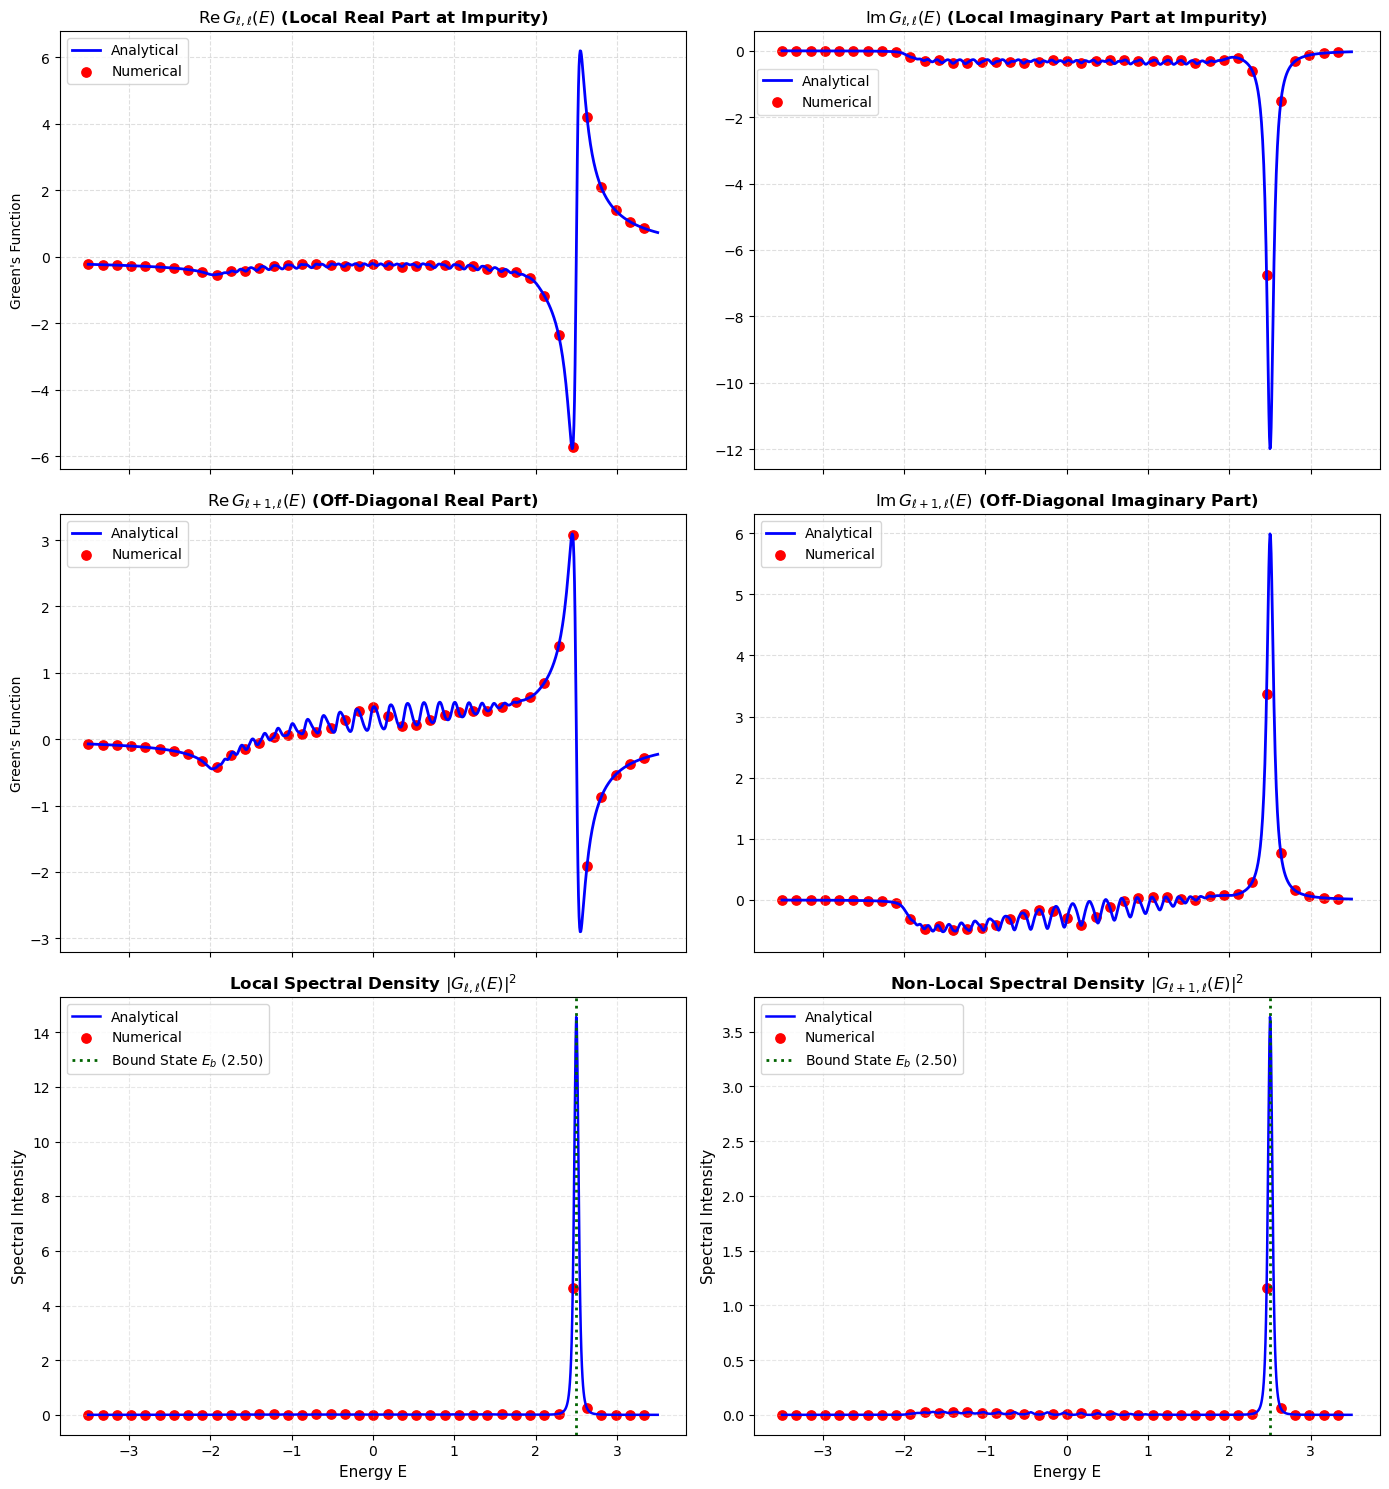

Mean Error for Re G(l,l):              7.407e-16
Mean Error for Im G(l,l):              6.638e-16
Mean Error for Re G(l+1,l):            4.360e-16
Mean Error for Im G(l+1,l):            4.017e-16
Mean Error for Local|G|^2:             8.341e-16
Mean Error for |G5,6|^2:               2.155e-16


In [198]:
import numpy as np
import matplotlib.pyplot as plt

# 1. System Parameters
N = 60          # Nomber of sites
t = 1.0         # Hopping parameter
epsilon_0 = 0.0 #  on-site energy
epsilon = 1.5   # Impurity potential strength
ell = N // 2    # Position of the single impurity 
a = 1.0         # Lattice constant
eta = 0.05      # Damping factor

# Energy resolution vector
E_values = np.linspace(-3.5, 3.5, 1000)

# 2. Numerical Hamiltonian Matrix Construction
H0 = np.zeros((N, N), dtype=complex)
for i in range(N - 1):
    H0[i, i + 1] = -t
    H0[i + 1, i] = -t
for i in range(N):
    H0[i, i] = epsilon_0

# Localized perturbation
H1 = np.zeros((N, N), dtype=complex)
H1[ell, ell] = epsilon

# Total perturbed Hamiltonian
H = H0 + H1

# 3. Calculation of Green's Functions (Analytical vs Numerical)
G_local_ana = []
G_non_ana = []
G_local_num = []
G_matrix_store = []

k_vals = (2 * np.pi / (N * a)) * np.arange(N)

for E in E_values:
    z = E + 1j * eta
    
    #  A) Exact Numerical Inversion 
    I = np.eye(N, dtype=complex)
    G_matrix = np.linalg.inv(z * I - H)
    G_matrix_store.append(G_matrix)
    
    #  B) Unperturbed Matrix Inversion 
    G0_matrix = np.linalg.inv(z * I - H0)
    
    G0_ll = G0_matrix[ell, ell]
    G0_nl = G0_matrix[ell, ell]     
    G0_lm = G0_matrix[ell, ell]     
    
    G0_nn_non = G0_matrix[ell + 1, ell + 1]
    G0_nl_non = G0_matrix[ell + 1, ell]
    G0_lm_non = G0_matrix[ell, ell + 1]
    
    G_loc_analytical = G0_matrix[ell, ell] + (G0_nl * epsilon * G0_lm) / (1.0 - epsilon * G0_ll)
    G_non_analytical = G0_matrix[ell + 1, ell] + (G0_nl_non * epsilon * G0_lm) / (1.0 - epsilon * G0_ll)
    
    G_local_ana.append(G_loc_analytical)
    G_non_ana.append(G_non_analytical)

G_local_ana = np.array(G_local_ana)
G_non_ana = np.array(G_non_ana)
G_local_num = np.array([G[ell, ell] for G in G_matrix_store])
G_non_num = np.array([G[ell + 1, ell] for G in G_matrix_store])

# 4. Perturbed Spectral Density Evaluation
A_local_ana = np.abs(-1.0 / np.pi * np.imag(G_local_ana))**2
A_non_ana   = np.abs(-1.0 / np.pi * np.imag(G_non_ana))**2

A_local_num = np.abs(-1.0 / np.pi * np.imag(G_local_num))**2
A_non_num   = np.abs(-1.0 / np.pi * np.imag(G_non_num))**2

# Theoretical Bound State Energy
E_b = epsilon_0 + np.sign(epsilon) * np.sqrt(epsilon**2 + 4.0 * t**2)

# 5. Plot Perturbed Green's Functions 
fig, axs1 = plt.subplots(3, 2, figsize=(14, 15), sharex=True)
step = 25  

# G(l,l) Real Part
axs1[0, 0].plot(E_values, np.real(G_local_ana), color='blue', linewidth=2, label='Analytical')
axs1[0, 0].scatter(E_values[::step], np.real(G_local_num)[::step], color='red', marker='o', s=45, label='Numerical')
axs1[0, 0].set_title(r"$\mathrm{Re}\,G_{\ell,\ell}(E)$ (Local Real Part at Impurity)", fontweight='bold')
axs1[0, 0].set_ylabel("Green's Function")
axs1[0, 0].grid(True, linestyle='--', alpha=0.4)
axs1[0, 0].legend(loc='upper left')

# G(l,l) Imaginary Part 
axs1[0, 1].plot(E_values, np.imag(G_local_ana), color='blue', linewidth=2, label='Analytical')
axs1[0, 1].scatter(E_values[::step], np.imag(G_local_num)[::step], color='red', marker='o', s=45, label='Numerical')
axs1[0, 1].set_title(r"$\mathrm{Im}\,G_{\ell,\ell}(E)$ (Local Imaginary Part at Impurity)", fontweight='bold')
axs1[0, 1].grid(True, linestyle='--', alpha=0.4)
axs1[0, 1].legend(bbox_to_anchor=(0.21, 0.93), loc='upper right', frameon=True, facecolor='white', edgecolor='lightgray')


# G(l+1,l) Real Part 
axs1[1, 0].plot(E_values, np.real(G_non_ana), color='blue', linewidth=2, label='Analytical')
axs1[1, 0].scatter(E_values[::step], np.real(G_non_num)[::step], color='red', marker='o', s=45, label='Numerical')
axs1[1, 0].set_title(r"$\mathrm{Re}\,G_{\ell+1,\ell}(E)$ (Off-Diagonal Real Part)", fontweight='bold')
axs1[1, 0].set_ylabel("Green's Function")
axs1[1, 0].grid(True, linestyle='--', alpha=0.4)
axs1[1, 0].legend(loc='upper left')

# G(l+1,l) Imaginary Part
axs1[1, 1].plot(E_values, np.imag(G_non_ana), color='blue', linewidth=2, label='Analytical')
axs1[1, 1].scatter(E_values[::step], np.imag(G_non_num)[::step], color='red', marker='o', s=45, label='Numerical')
axs1[1, 1].set_title(r"$\mathrm{Im}\,G_{\ell+1,\ell}(E)$ (Off-Diagonal Imaginary Part)", fontweight='bold')
axs1[1, 1].grid(True, linestyle='--', alpha=0.4)
axs1[1, 1].legend(loc='upper left')


# Local Density
axs1[2, 0].plot(E_values, A_local_ana, color='blue', linewidth=1.8, label='Analytical')
axs1[2, 0].scatter(E_values[::step], A_local_num[::step], color='red', marker='o', s=45, label='Numerical')
axs1[2, 0].axvline(x=E_b, color='darkgreen', linestyle=':', linewidth=2, label=f'Bound State $E_b$ ({E_b:.2f})')
axs1[2, 0].set_title(r"Local Spectral Density $|G_{\ell,\ell}(E)|^2$", fontweight='bold', fontsize=12)
axs1[2, 0].set_xlabel("Energy E", fontsize=11)
axs1[2, 0].set_ylabel("Spectral Intensity", fontsize=11)
axs1[2, 0].grid(True, linestyle='--', alpha=0.3)
axs1[2, 0].legend(loc='upper left')

# Non-Local Density
axs1[2, 1].plot(E_values, A_non_ana, color='blue', linewidth=1.8, label='Analytical')
axs1[2, 1].scatter(E_values[::step], A_non_num[::step], color='red', marker='o', s=45, label='Numerical')
axs1[2, 1].axvline(x=E_b, color='darkgreen', linestyle=':', linewidth=2, label=f'Bound State $E_b$ ({E_b:.2f})')
axs1[2, 1].set_title(r"Non-Local Spectral Density $|G_{\ell+1,\ell}(E)|^2$", fontweight='bold', fontsize=12)
axs1[2, 1].set_xlabel("Energy E", fontsize=11)
axs1[2, 1].set_ylabel("Spectral Intensity", fontsize=11)
axs1[2, 1].grid(True, linestyle='--', alpha=0.3)
axs1[2, 1].legend(loc='upper left')

plt.tight_layout()
plt.savefig("Impurity_Greens_Function.png", dpi=300)
plt.show()

# 7. Mean Error 

error_G_local_real = np.abs(np.real(G_local_ana) - np.real(G_local_num))
error_G_local_imag = np.abs(np.imag(G_local_ana) - np.imag(G_local_num))
error_G_non_real   = np.abs(np.real(G_non_ana) - np.real(G_non_num))
error_G_non_imag   = np.abs(np.imag(G_non_ana) - np.imag(G_non_num))
error_A_loc        = np.abs(A_local_ana - A_local_num)
error_A_non        = np.abs(A_non_ana - A_non_num)

print(f"Mean Error for Re G(l,l):              {np.mean(error_G_local_real):.3e}")
print(f"Mean Error for Im G(l,l):              {np.mean(error_G_local_imag):.3e}")
print(f"Mean Error for Re G(l+1,l):            {np.mean(error_G_non_real):.3e}")
print(f"Mean Error for Im G(l+1,l):            {np.mean(error_G_non_imag):.3e}")
print(f"Mean Error for Local|G|^2:             {np.mean(error_A_loc):.3e}")
print(f"Mean Error for |G5,6|^2:               {np.mean(error_A_non):.3e}")

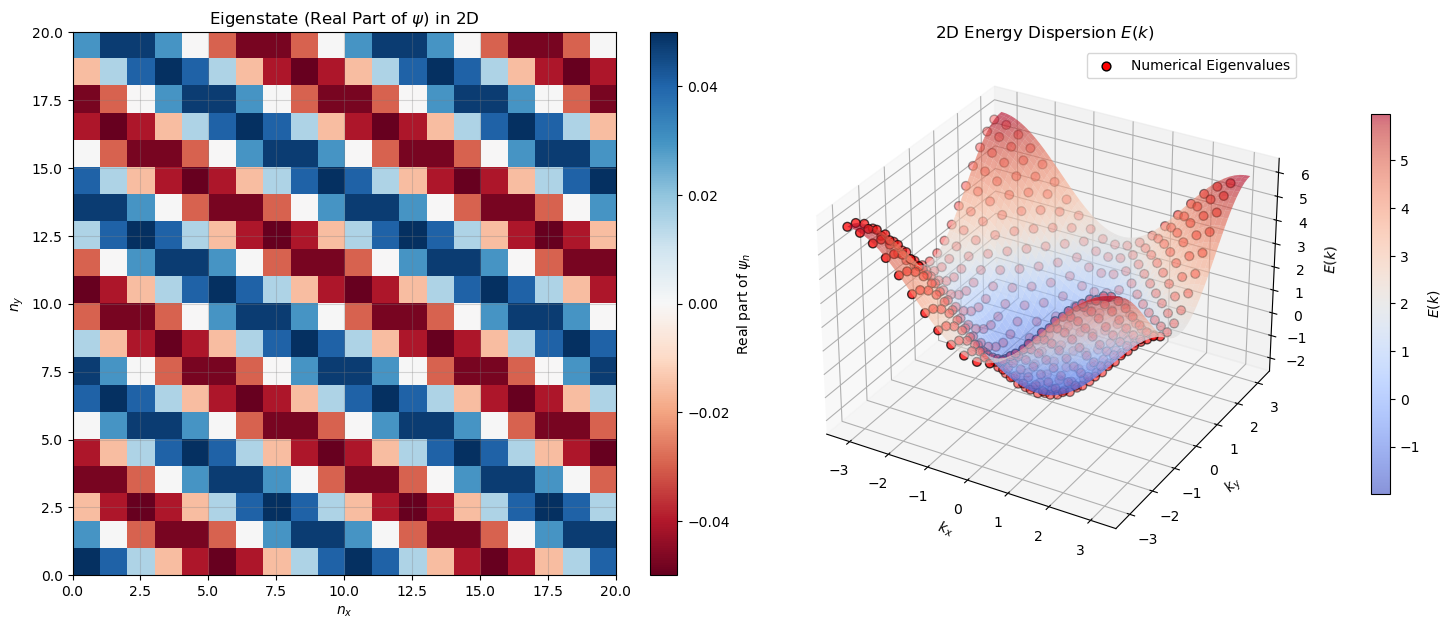

Mean Error for 2D Energy Spectrum E(k): 2.439e-15


In [188]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 1. System Parameters
Nx = 20           # Number of atoms in x-direction
Ny = 20           # Number of atoms in y-direction
N = Nx * Ny       # Total number of atoms 
t = 1             # Hopping parameter 
E0 = 2            # On-site energy 
a = 1             # Lattice constant 


# 2. Energy Dispersion Data (Right Plot)

# Continuous analytical grid for the smooth surface
kx_ana = np.linspace(-np.pi/a, np.pi/a, 50)
ky_ana = np.linspace(-np.pi/a, np.pi/a, 50)
KX_ana, KY_ana = np.meshgrid(kx_ana, ky_ana)
E_ana2 = E0 - 2 * t * (np.cos(KX_ana * a) + np.cos(KY_ana * a))

# Discrete numerical k-points 
Nx_pts, Ny_pts = 20, 20
mx = np.arange(Nx_pts) - Nx_pts//2
my = np.arange(Ny_pts) - Ny_pts//2
kx_num = (2 * np.pi * mx) / (Nx_pts * a)
ky_num = (2 * np.pi * my) / (Ny_pts * a)
KX_num, KY_num = np.meshgrid(kx_num, ky_num)

E_points = E0 - 2 * t * (np.cos(KX_num * a) + np.cos(KY_num * a))

# 3. Eigenstate Data 
nx = np.arange(Nx)
ny = np.arange(Ny)
nx_grid, ny_grid = np.meshgrid(nx, ny)
mx_state = 2  
my_state = 3  
kx_state = (2 * np.pi * mx_state) / (Nx * a)
ky_state = (2 * np.pi * my_state) / (Ny * a)

# Plane Wave Equation
psi = (1 / np.sqrt(Nx * Ny)) * np.exp(1j * (kx_state * nx_grid + ky_state * ny_grid))
wave_real = np.real(psi) 

# 4. Plotting

fig = plt.figure(figsize=(15, 6))

#  Real Part of the Eigenstate 
ax1 = fig.add_subplot(121)
im = ax1.imshow(wave_real, cmap='RdBu', origin='lower', extent=[0, Nx, 0, Ny])
fig.colorbar(im, ax=ax1, label='Real part of $\psi_{n}$')
ax1.set_title(r'Eigenstate (Real Part of $\psi$) in 2D')
ax1.set_xlabel('$n_x$')
ax1.set_ylabel('$n_y$')
ax1.grid(True, color='gray', linestyle='-', alpha=0.3)

# 3D Energy Dispersion Surface 
ax2 = fig.add_subplot(122, projection='3d')
surf = ax2.plot_surface(KX_ana, KY_ana, E_ana2, cmap='coolwarm', alpha=0.6, antialiased=True)
ax2.scatter(KX_num, KY_num, E_points, color='red', s=40, label='Numerical Eigenvalues', edgecolors='black')

ax2.set_title("2D Energy Dispersion $E(k)$")
ax2.set_xlabel("$k_x$")
ax2.set_ylabel("$k_y$")
ax2.set_zlabel("$E(k)$")
ax2.legend(loc='upper right')

fig.colorbar(surf, ax=ax2, pad=0.1, shrink=0.7, label='$E(k)$')

plt.tight_layout()
plt.savefig("proba_Energy_2D.png", dpi=300, bbox_inches='tight')
plt.show()


# 5.  2D Error Tracking 

dx = np.eye(Nx, k=1) + np.eye(Nx, k=-1)
dx[0, -1], dx[-1, 0] = 1, 1 
dy = np.eye(Ny, k=1) + np.eye(Ny, k=-1)
dy[0, -1], dy[-1, 0] = 1, 1 
H_2D = E0 * np.eye(N) - t * (np.kron(dx, np.eye(Ny)) + np.kron(np.eye(Nx), dy))
E_Num_Sorted = np.sort(np.linalg.eigvalsh(H_2D))
error_E_2D = np.abs(E_Num_Sorted - np.sort(E_points.flatten()))

print(f"Mean Error for 2D Energy Spectrum E(k): {np.mean(error_E_2D):.3e}")

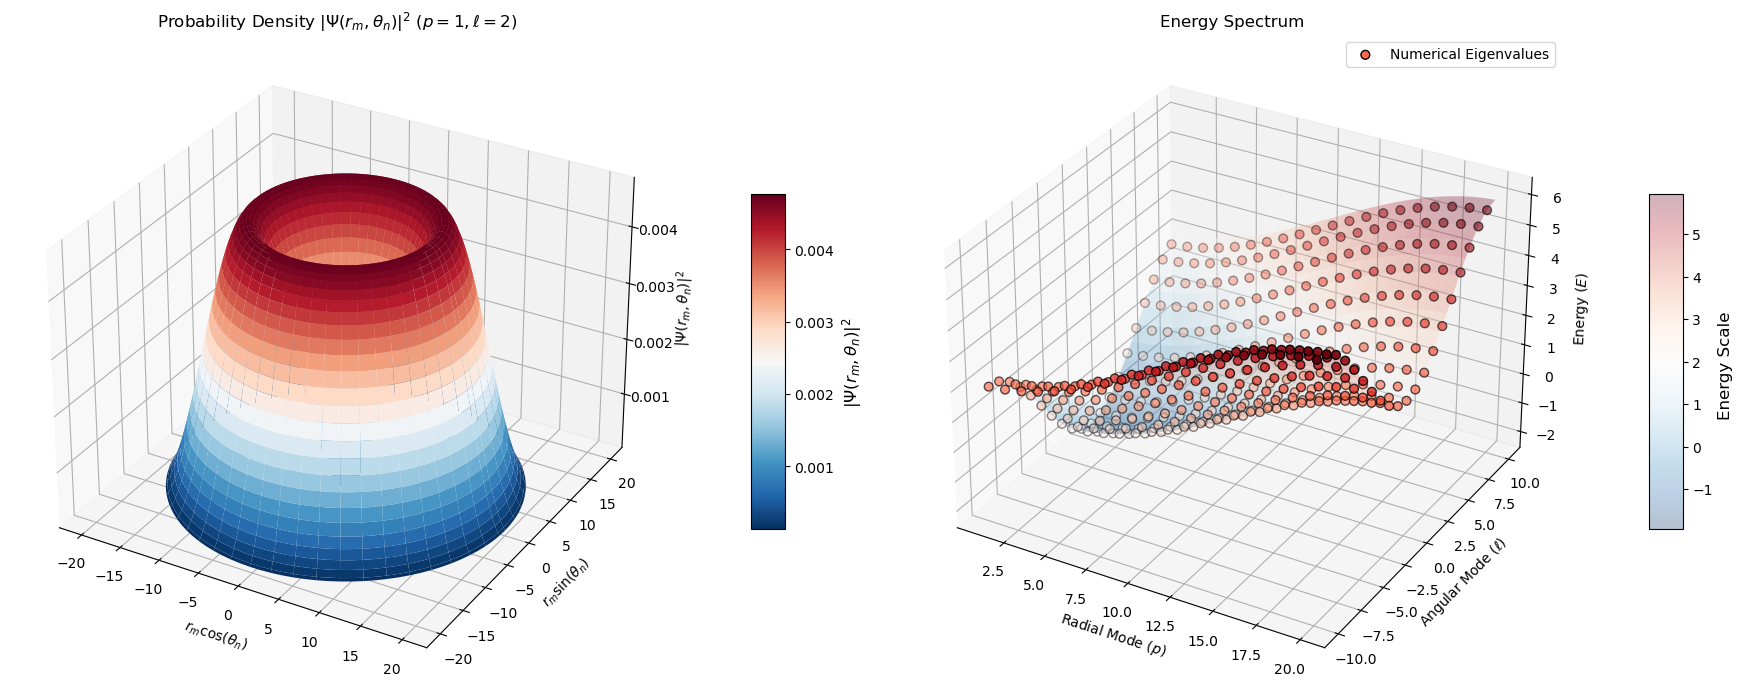

Maximum difference: 1.47e-14


In [189]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. System parameters:
M = 20  # Number of rings
N = 20  # Number of atoms per ring
tr = 1.0  # Radial hopping 
tth = 1.0 # Angular hopping 
E0 = 2.0  # On-site energy
Ntot = M * N # Total number of atoms

# PART A: Numerical Diagonalization (Hamiltonian)
H = np.zeros((Ntot, Ntot))
def get_idx(r, n): return r * N + n

for r in range(M):
    for n in range(N):
        idx = get_idx(r, n)
        H[idx, idx] = E0
        H[idx, get_idx(r, (n + 1) % N)] = -tth
        H[get_idx(r, (n + 1) % N), idx] = -tth
        if r < M - 1:
            H[idx, get_idx(r + 1, n)] = -tr
            H[get_idx(r + 1, n), idx] = -tr

E_num_sorted = np.sort(np.linalg.eigvalsh(H))

# PART B: Analytical Energy Spectrum
E_ana_list, P_list, L_list = [], [], []
for p in range(1, M+1):
    for l in range(-N//2, N//2):
        energy = E0 - 2*tr*np.cos(p*np.pi/(M+1)) - 2*tth*np.cos(2*np.pi*l/N)
        E_ana_list.append(energy)
        P_list.append(p)
        L_list.append(l)
E_ana_sorted = np.sort(E_ana_list)

# PART C: Probability Density
p_target, l_target = 1, 2
r_fine = np.linspace(1, M, 100)
th_fine = np.linspace(0, 2*np.pi, 100)
RF, THF = np.meshgrid(r_fine, th_fine)
prob_density = (np.sqrt(2/(M+1)) * np.sin(p_target * np.pi * RF / (M+1)))**2 * (1/N)
X_dens, Y_dens = RF * np.cos(THF), RF * np.sin(THF)

# PART D: VISUALIZATION
fig = plt.figure(figsize=(18, 7))

# 1. Probability Density 

ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X_dens, Y_dens, prob_density, cmap='RdBu_r', antialiased=True)
cbar1 = fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, pad=0.1)
cbar1.set_label('$|\Psi(r_m, \\theta_n)|^2$', fontsize=12)

ax1.set_xlabel('$r_m \cos(\\theta_n)$')
ax1.set_ylabel('$r_m \sin(\\theta_n)$')
ax1.set_zlabel('$|\Psi(r_m, \\theta_n)|^2$')
ax1.set_title(f'Probability Density $|\Psi(r_m, \\theta_n)|^2$ ($p={p_target}, \ell={l_target}$)')

# 2. Plot Analytical spectrum energy  
ax2 = fig.add_subplot(122, projection='3d')
p_f = np.linspace(1, M, 30)
l_f = np.linspace(-N//2, N//2, 30)
PF, LF = np.meshgrid(p_f, l_f)
EF = E0 - 2*tr*np.cos(PF*np.pi/(M+1)) - 2*tth*np.cos(2*np.pi*LF/N)
surf2 = ax2.plot_surface(PF, LF, EF, cmap='RdBu_r', alpha=0.3, antialiased=True)

# 3. Plot Numerical Eigenvalues
scat = ax2.scatter(P_list, L_list, E_ana_list, c=E_ana_list, cmap='Reds', s=40, edgecolors='black', label='Numerical Eigenvalues')


cbar2 = fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, pad=0.1)
cbar2.set_label('Energy Scale ', fontsize=12)

ax2.set_xlabel('Radial Mode ($p$)')
ax2.set_ylabel('Angular Mode ($\ell$)')
ax2.set_zlabel('Energy ($E$)')
ax2.set_title('Energy Spectrum ')
ax2.legend()

plt.tight_layout()
plt.savefig('Rotaion.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Precision Check
max_diff = np.max(np.abs(E_num_sorted - E_ana_sorted))
print(f"Maximum difference: {max_diff:.2e}")

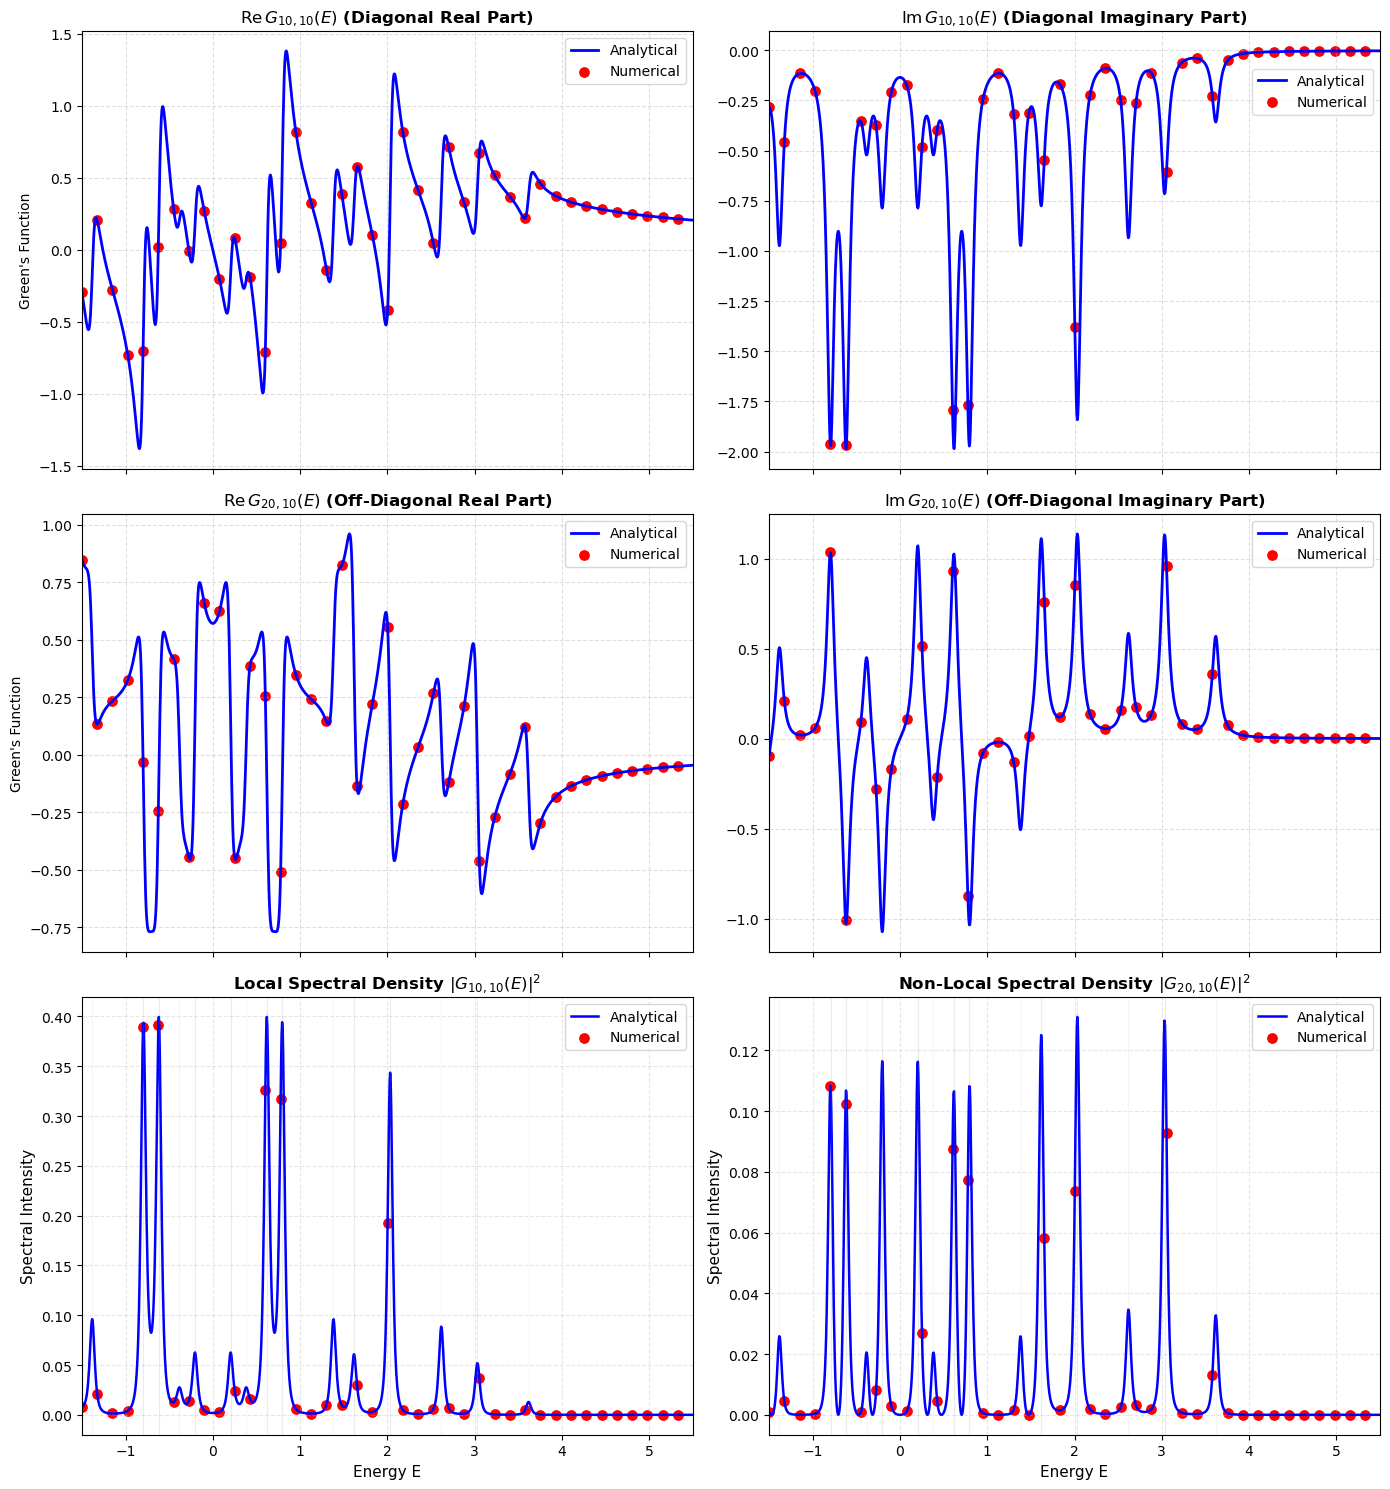

Mean Error for Re G10,10:    6.044e-16
Mean Error for Im G10,10:    6.073e-16
Mean Error for Re G20,10:    4.980e-16
Mean Error for Im G20,10:    5.414e-16
Mean Error for |G10,10|^2:   9.850e-17
Mean Error for |G20,10|^2:   5.079e-17


In [201]:
import numpy as np
import matplotlib.pyplot as plt

# 1. System Parameters
M = 4               # Number of rings
N = 8               # Number of atoms per ring
Total_Sites = M * N # Total number of lattice sites
tr = 1.0            # Radial hopping amplitude
tth = 1.0           # Angular hopping amplitude
epsilon_0 = 0.0     # On-site energy
phi = 2 * np.pi / N # Angular step size
a = 1.0             # Radial step size
eta = 0.05          # Damping factor for Green's functions    

E_values = np.linspace(-1.5, 5.5, 1200)

# 2. Numerical Hamiltonian Matrix Construction
H = np.zeros((Total_Sites, Total_Sites), dtype=complex)
for m in range(M):
    for n in range(N):
        idx = m * N + n
        H[idx, idx] = epsilon_0
        
        # Angular hopping 
        H[idx, m * N + ((n + 1) % N)] = -tth
        H[idx, m * N + ((n - 1) % N)] = -tth
        
        # Radial hopping 
        if m + 1 < M:
            H[idx, (m + 1) * N + n] = -tr
        if m - 1 >= 0:
            H[idx, (m - 1) * N + n] = -tr


# 3. Simulation Loop 
G_local_ana = []
G_non_ana = []
G_local_num = []
G_non_num = []

# Indices 
idx_local_num = 0 * N + 0   
idx_non_local_num = 1 * N + 0   

for E in E_values:
    z = E + 1j * eta
    
    # A) Analytical Calculation
    t_loc, t_non = 0.0, 0.0
    for l in range(N):
        z_eff = z - epsilon_0 + 2 * tth * np.cos(l * phi)
        ka = np.lib.scimath.arccos(-z_eff / (2 * tr))
        
        num_loc = np.sin(ka * 1) * np.sin(ka * (1 - 1 - M))
        num_non = np.sin(ka * 1) * np.sin(ka * (2 - 1 - M))
        den = tr * np.sin(ka) * np.sin(ka * (M + 1))
        
        t_loc += (1.0 / N) * (num_loc / den)
        t_non += (1.0 / N) * (num_non / den)
        
    G_local_ana.append(t_loc)
    G_non_ana.append(t_non)
    
    #  B) Numerical Matrix Inversion 
    I = np.eye(Total_Sites, dtype=complex)
    G_matrix = np.linalg.inv(z * I - H)
    G_local_num.append(G_matrix[idx_local_num, idx_local_num])
    G_non_num.append(G_matrix[idx_non_local_num, idx_local_num])

G_local_ana, G_non_ana = np.array(G_local_ana), np.array(G_non_ana)
G_local_num, G_non_num = np.array(G_local_num), np.array(G_non_num)

# 4. Spectral Density Derivation
A_local_ana = np.abs(-1.0 / np.pi * np.imag(G_local_ana))**2
A_non_ana   = np.abs(-1.0 / np.pi * np.imag(G_non_ana))**2

A_local_num = np.abs(-1.0 / np.pi * np.imag(G_local_num))**2
A_non_num   = np.abs(-1.0 / np.pi * np.imag(G_non_num))**2

# Exact theoretical eigenvalues
energy_levels = [epsilon_0 - 2*tth*np.cos(l*phi) - 2*tr*np.cos(p*np.pi/(M+1)) for l in range(N) for p in range(1, M+1)]

# Plotting

fig, axs1 = plt.subplots(3, 2, figsize=(14, 15), sharex=True)
step_g = 30 

# - G10,10 Real Part
axs1[0, 0].plot(E_values, np.real(G_local_ana), color='blue', linewidth=2, label='Analytical')
axs1[0, 0].scatter(E_values[::step_g], np.real(G_local_num)[::step_g], color='red', marker='o', s=45, label='Numerical')
axs1[0, 0].set_title(r"$\mathrm{Re}\,G_{10,10}(E)$ (Diagonal Real Part)", fontweight='bold')
axs1[0, 0].set_ylabel("Green's Function")
axs1[0, 0].grid(True, linestyle='--', alpha=0.4)
axs1[0, 0].legend(loc='upper right')

#  G10,10 Imaginary Part
axs1[0, 1].plot(E_values, np.imag(G_local_ana), color='blue', linewidth=2, label='Analytical')
axs1[0, 1].scatter(E_values[::step_g], np.imag(G_local_num)[::step_g], color='red', marker='o', s=45, label='Numerical')
axs1[0, 1].set_title(r"$\mathrm{Im}\,G_{10,10}(E)$ (Diagonal Imaginary Part)", fontweight='bold')
axs1[0, 1].grid(True, linestyle='--', alpha=0.4)
axs1[0, 1].legend(bbox_to_anchor=(1.00, 0.93), loc='upper right', frameon=True, facecolor='white', edgecolor='lightgray')

# G20,10 Real Part 
axs1[1, 0].plot(E_values, np.real(G_non_ana), color='blue', linewidth=2, label='Analytical')
axs1[1, 0].scatter(E_values[::step_g], np.real(G_non_num)[::step_g], color='red', marker='o', s=45, label='Numerical')
axs1[1, 0].set_title(r"$\mathrm{Re}\,G_{20,10}(E)$ (Off-Diagonal Real Part)", fontweight='bold')
axs1[1, 0].set_ylabel("Green's Function")
axs1[1, 0].grid(True, linestyle='--', alpha=0.4)
axs1[1, 0].legend(loc='upper right')

# G20,10 Imaginary Part 
axs1[1, 1].plot(E_values, np.imag(G_non_ana), color='blue', linewidth=2, label='Analytical')
axs1[1, 1].scatter(E_values[::step_g], np.imag(G_non_num)[::step_g], color='red', marker='o', s=45, label='Numerical')
axs1[1, 1].set_title(r"$\mathrm{Im}\,G_{20,10}(E)$ (Off-Diagonal Imaginary Part)", fontweight='bold')
axs1[1, 1].set_xlim(-1.5, 5.5)
axs1[1, 1].grid(True, linestyle='--', alpha=0.4)
axs1[1, 1].legend(loc='upper right')


# Local Spectral Density 
axs1[2, 0].plot(E_values, A_local_ana, color='blue', linewidth=1.8, label='Analytical')
axs1[2, 0].scatter(E_values[::step_g], A_local_num[::step_g], color='red', marker='o', s=45, label='Numerical')

for E_lvl in energy_levels: 
    axs1[2, 0].axvline(x=E_lvl, color='gray', alpha=0.08, linewidth=0.8)
axs1[2, 0].set_title(r"Local Spectral Density $|G_{10,10}(E)|^2$", fontweight='bold', fontsize=12)
axs1[2, 0].set_xlabel("Energy E", fontsize=11)
axs1[2, 0].set_ylabel("Spectral Intensity", fontsize=11)
axs1[2, 0].set_xlim(-1.5, 5.5)
axs1[2, 0].grid(True, linestyle='--', alpha=0.3)
axs1[2, 0].legend(loc='upper right') 

# Non-Local Spectral Density 
axs1[2, 1].plot(E_values, A_non_ana, color='blue', linewidth=1.8, label='Analytical')
axs1[2, 1].scatter(E_values[::step_g], A_non_num[::step_g], color='red', marker='o', s=45, label='Numerical')

for E_lvl in energy_levels: 
    axs1[2, 1].axvline(x=E_lvl, color='gray', alpha=0.08, linewidth=0.8)
axs1[2, 1].set_title(r"Non-Local Spectral Density $|G_{20,10}(E)|^2$", fontweight='bold', fontsize=12)
axs1[2, 1].set_xlabel("Energy E", fontsize=11)
axs1[2, 1].set_ylabel("Spectral Intensity", fontsize=11)
axs1[2, 1].set_xlim(-1.5, 5.5)
axs1[2, 1].grid(True, linestyle='--', alpha=0.3)
axs1[2, 1].legend(loc='upper right') 

plt.tight_layout()
plt.savefig("Green_Chapter3.png", dpi=300)
plt.show()


# 7.  Mean Error 
error_G11_real = np.abs(np.real(G_local_ana) - np.real(G_local_num))
error_G11_imag = np.abs(np.imag(G_local_ana) - np.imag(G_local_num))
error_G21_real = np.abs(np.real(G_non_ana) - np.real(G_non_num))
error_G21_imag = np.abs(np.imag(G_non_ana) - np.imag(G_non_num))

absolute_error_A10_10 = np.abs(A_local_ana - A_local_num)
absolute_error_A20_10 = np.abs(A_non_ana - A_non_num)

print(f"Mean Error for Re G10,10:    {np.mean(error_G11_real):.3e}")
print(f"Mean Error for Im G10,10:    {np.mean(error_G11_imag):.3e}")
print(f"Mean Error for Re G20,10:    {np.mean(error_G21_real):.3e}")
print(f"Mean Error for Im G20,10:    {np.mean(error_G21_imag):.3e}")
print(f"Mean Error for |G10,10|^2:   {np.mean(absolute_error_A10_10):.3e}")
print(f"Mean Error for |G20,10|^2:   {np.mean(absolute_error_A20_10):.3e}")